In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

df = pd.read_csv('../data/processed/trip_features.csv')

df['safety_score'] = (df['count_hard_brakes'] * 3.0) + \
                     (df['harsh_accel_count'] * 2.0) + \
                     (df['max_speed'] * 0.1)

df.to_csv('../data/processed/trip_features.csv', index=False)

X = df.drop(columns=['vehicleId', 'safety_score'])
y = df['safety_score']

print("File updated and saved! Columns now include:", df.columns.tolist())

File updated and saved! Columns now include: ['vehicleId', 'duration_sec', 'distance_km', 'avg_speed', 'max_speed', 'speed_std', 'mean_accel', 'max_accel', 'accel_std', 'count_hard_brakes', 'harsh_accel_count', 'idling_time', 'stop_count', 'day_of_week', 'hour_of_day', 'safety_score']


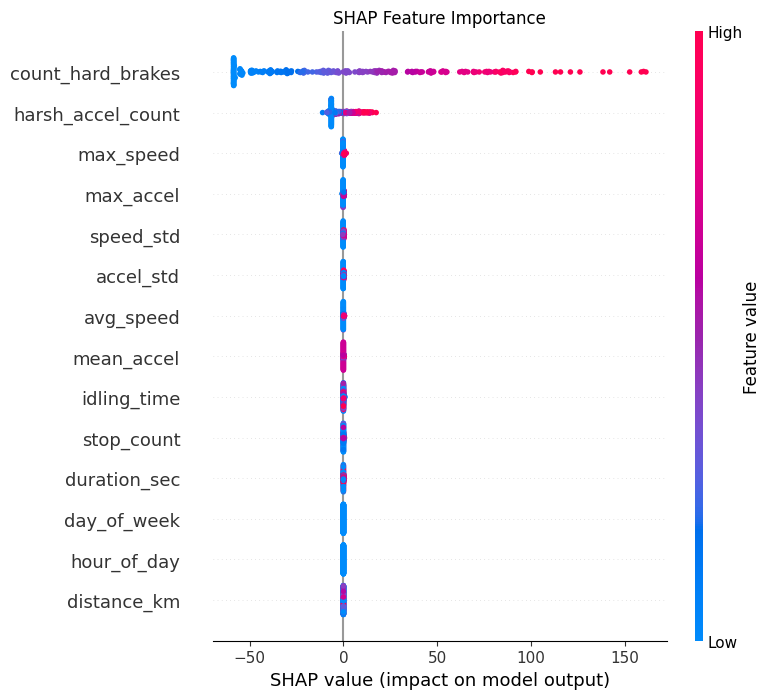

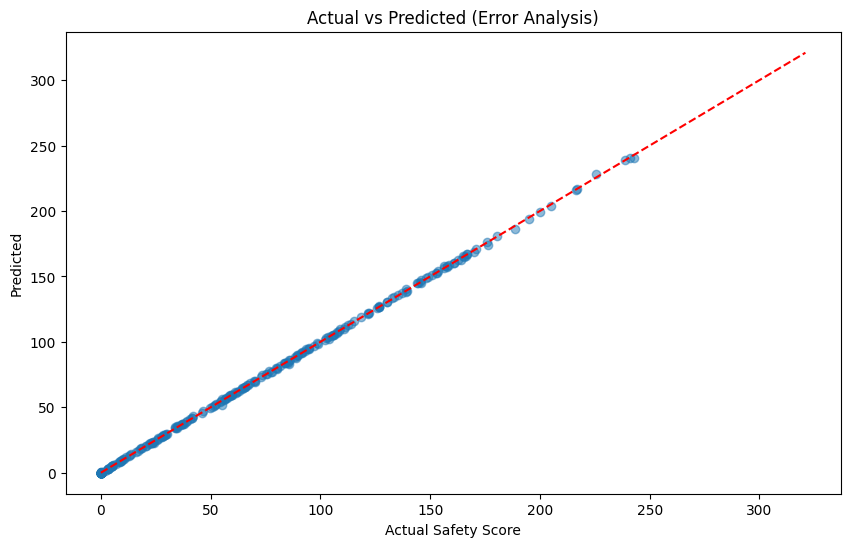

     duration_sec   distance_km  avg_speed  max_speed  speed_std  \
350      0.000002  4.289594e-09   5.580656  69.597652  13.667233   
479      0.000002  1.580277e-08  29.011494  64.986718  18.141388   
482      0.000002  6.862970e-09   9.358552  37.659502  11.147694   
802      0.000001  4.150579e-09  24.858080  58.176560  17.942396   
666      0.000002  1.760634e-08  22.809355  61.595702  25.004017   

       mean_accel     max_accel     accel_std  count_hard_brakes  \
350  2.919209e+07  6.858724e+08  1.458962e+08                6.0   
479  2.982734e+06  1.205982e+09  3.512630e+08               45.0   
482  1.880190e+06  7.771701e+08  1.962183e+08               35.0   
802  3.922763e+07  7.128038e+08  3.873261e+08               12.0   
666  6.347880e+06  1.270580e+09  3.254313e+08               36.0   

     harsh_accel_count   idling_time  stop_count  day_of_week  hour_of_day  \
350               15.0  1.030000e-06         1.0          3.0          0.0   
479               42.0  1.

In [6]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/trip_features.csv')
X = df.drop(columns=['vehicleId', 'safety_score'])
y = df['safety_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = joblib.load('../models/baseline_model.pkl')

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.title("SHAP Feature Importance")
shap.summary_plot(shap_values, X_test)

y_pred = model.predict(X_test)
errors = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Safety Score")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Error Analysis)")
plt.show()

error_df = X_test.copy()
error_df['actual'] = y_test
error_df['pred'] = y_pred
error_df['abs_error'] = abs(errors)
print(error_df.sort_values('abs_error', ascending=False).head(5))

In [7]:
import joblib
joblib.dump(model, '../models/safety_model.pkl')

['../models/safety_model.pkl']